# 01 — Exploratory Data Analysis
**Project:** Customer Churn Prediction  
**Dataset:** IBM Telco Customer Churn  
**Goal:** Understand the data structure, distributions, class imbalance, and which features show the strongest signal for churn.

## 0. Imports & Config

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot config
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

RANDOM_STATE = 42
DATA_PATH = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

---
## 1. Load Data

In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## 2. Data Structure

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.00,7043,7043,7043.00,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.00,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.16,NaN,NaN,32.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.76,NaN,NaN
std,NaN,NaN,0.37,NaN,NaN,24.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.09,NaN,NaN
min,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.25,NaN,NaN
25%,NaN,NaN,0.00,NaN,NaN,9.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.50,NaN,NaN
50%,NaN,NaN,0.00,NaN,NaN,29.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.35,NaN,NaN
75%,NaN,NaN,0.00,NaN,NaN,55.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.85,NaN,NaN


### 2.1 Known Data Type Issue — TotalCharges

`TotalCharges` is loaded as `object` because some entries are whitespace strings (new customers with zero tenure). We fix this here and track how many rows are affected.

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

n_nulls = df['TotalCharges'].isna().sum()
print(f'TotalCharges NaNs after coercion: {n_nulls}')
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]

TotalCharges NaNs after coercion: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


> **Note:** These are customers with `tenure == 0`. We will decide in the feature engineering notebook whether to drop or impute them.

---
## 3. Missing Values

Columns with missing values:
TotalCharges    11
dtype: int64


FileNotFoundError: [Errno 2] No such file or directory: '../figures/missing_values.png'

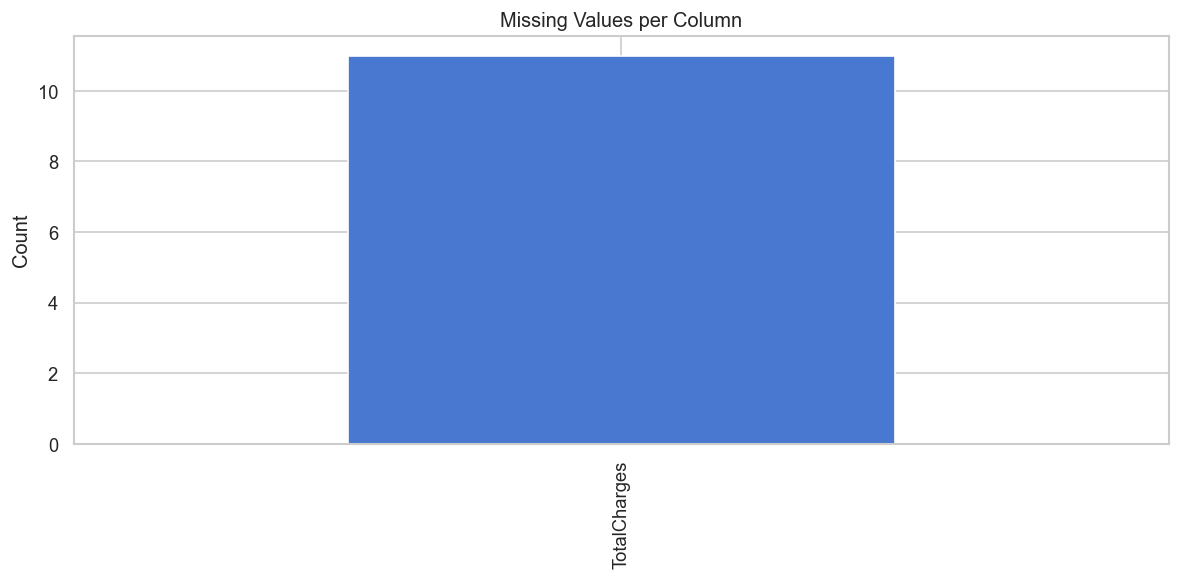

In [11]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print('Columns with missing values:')
print(missing)

# Visual
if not missing.empty:
    missing.plot(kind='bar', title='Missing Values per Column')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('../figures/missing_values.png' )
    plt.show()
else:
    print('No missing values beyond TotalCharges coercion.')

---
## 4. Target Variable — Churn Distribution

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No    73.46
Yes   26.54
Name: proportion, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/churn_distribution.png'

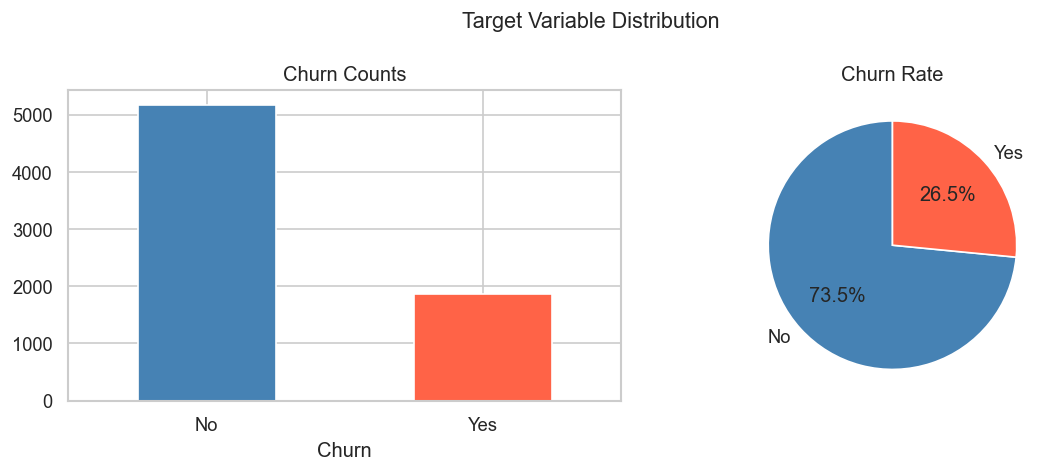

In [12]:
# Encode target for downstream analysis
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Churn Counts')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

axes[1].pie(churn_counts, labels=['No', 'Yes'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Churn Rate')

plt.suptitle('Target Variable Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png')
plt.show()

> **Takeaway:** The dataset is imbalanced (~26% churn). We will need to handle this during modeling via class weights, SMOTE, or threshold tuning — **not** by optimizing accuracy.

---
## 5. Numerical Features

FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/numerical_distributions.png'

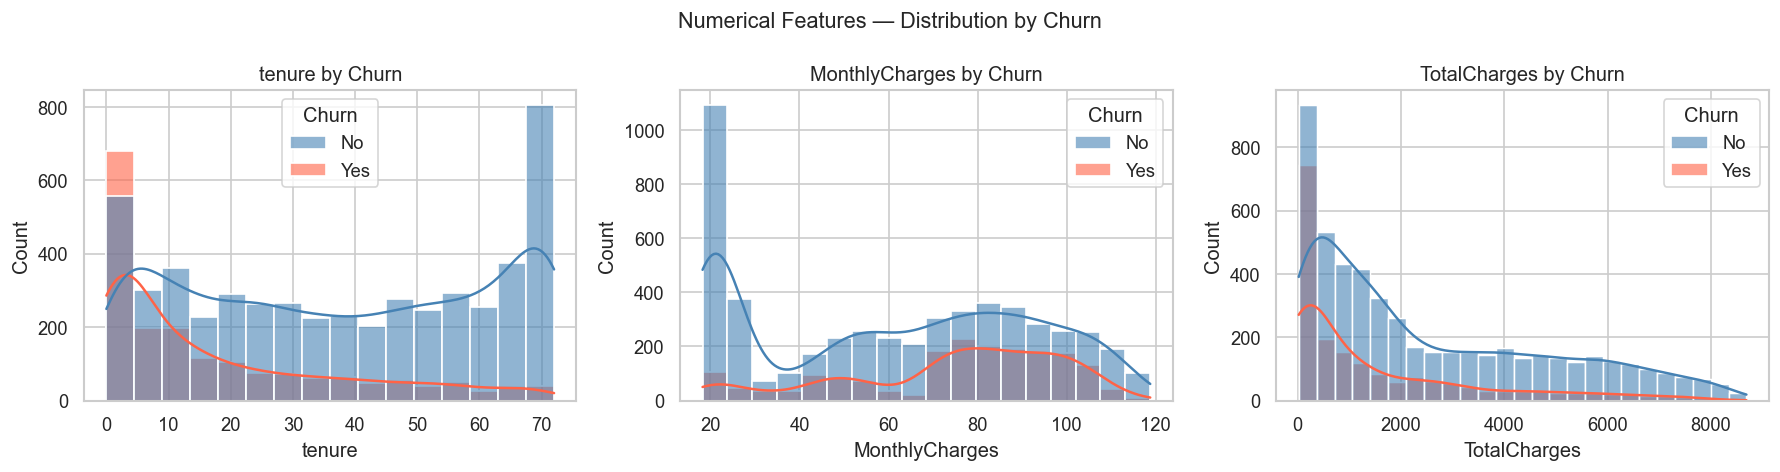

In [13]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax,
                 palette={'No': 'steelblue', 'Yes': 'tomato'}, alpha=0.6)
    ax.set_title(f'{col} by Churn')

plt.suptitle('Numerical Features — Distribution by Churn', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/numerical_distributions.png')
plt.show()

In [ ]:
# Boxplots — easier to spot median shifts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax,
                palette={'No': 'steelblue', 'Yes': 'tomato'})
    ax.set_title(f'{col} by Churn')

plt.suptitle('Numerical Features — Boxplots by Churn', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/numerical_boxplots.png')
plt.show()

> **Expected findings:**
> - Churners tend to have **lower tenure** (newer customers leave more)
> - Churners tend to have **higher monthly charges**
> - `TotalCharges` is highly correlated with tenure — expected

---
## 6. Categorical Features

In [14]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', 'Churn']]
print(f'{len(cat_cols)} categorical features: {cat_cols}')

15 categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\santi\AppData\Local\Temp\ipykernel_27528\2545785498.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/categorical_churn_rates.png'

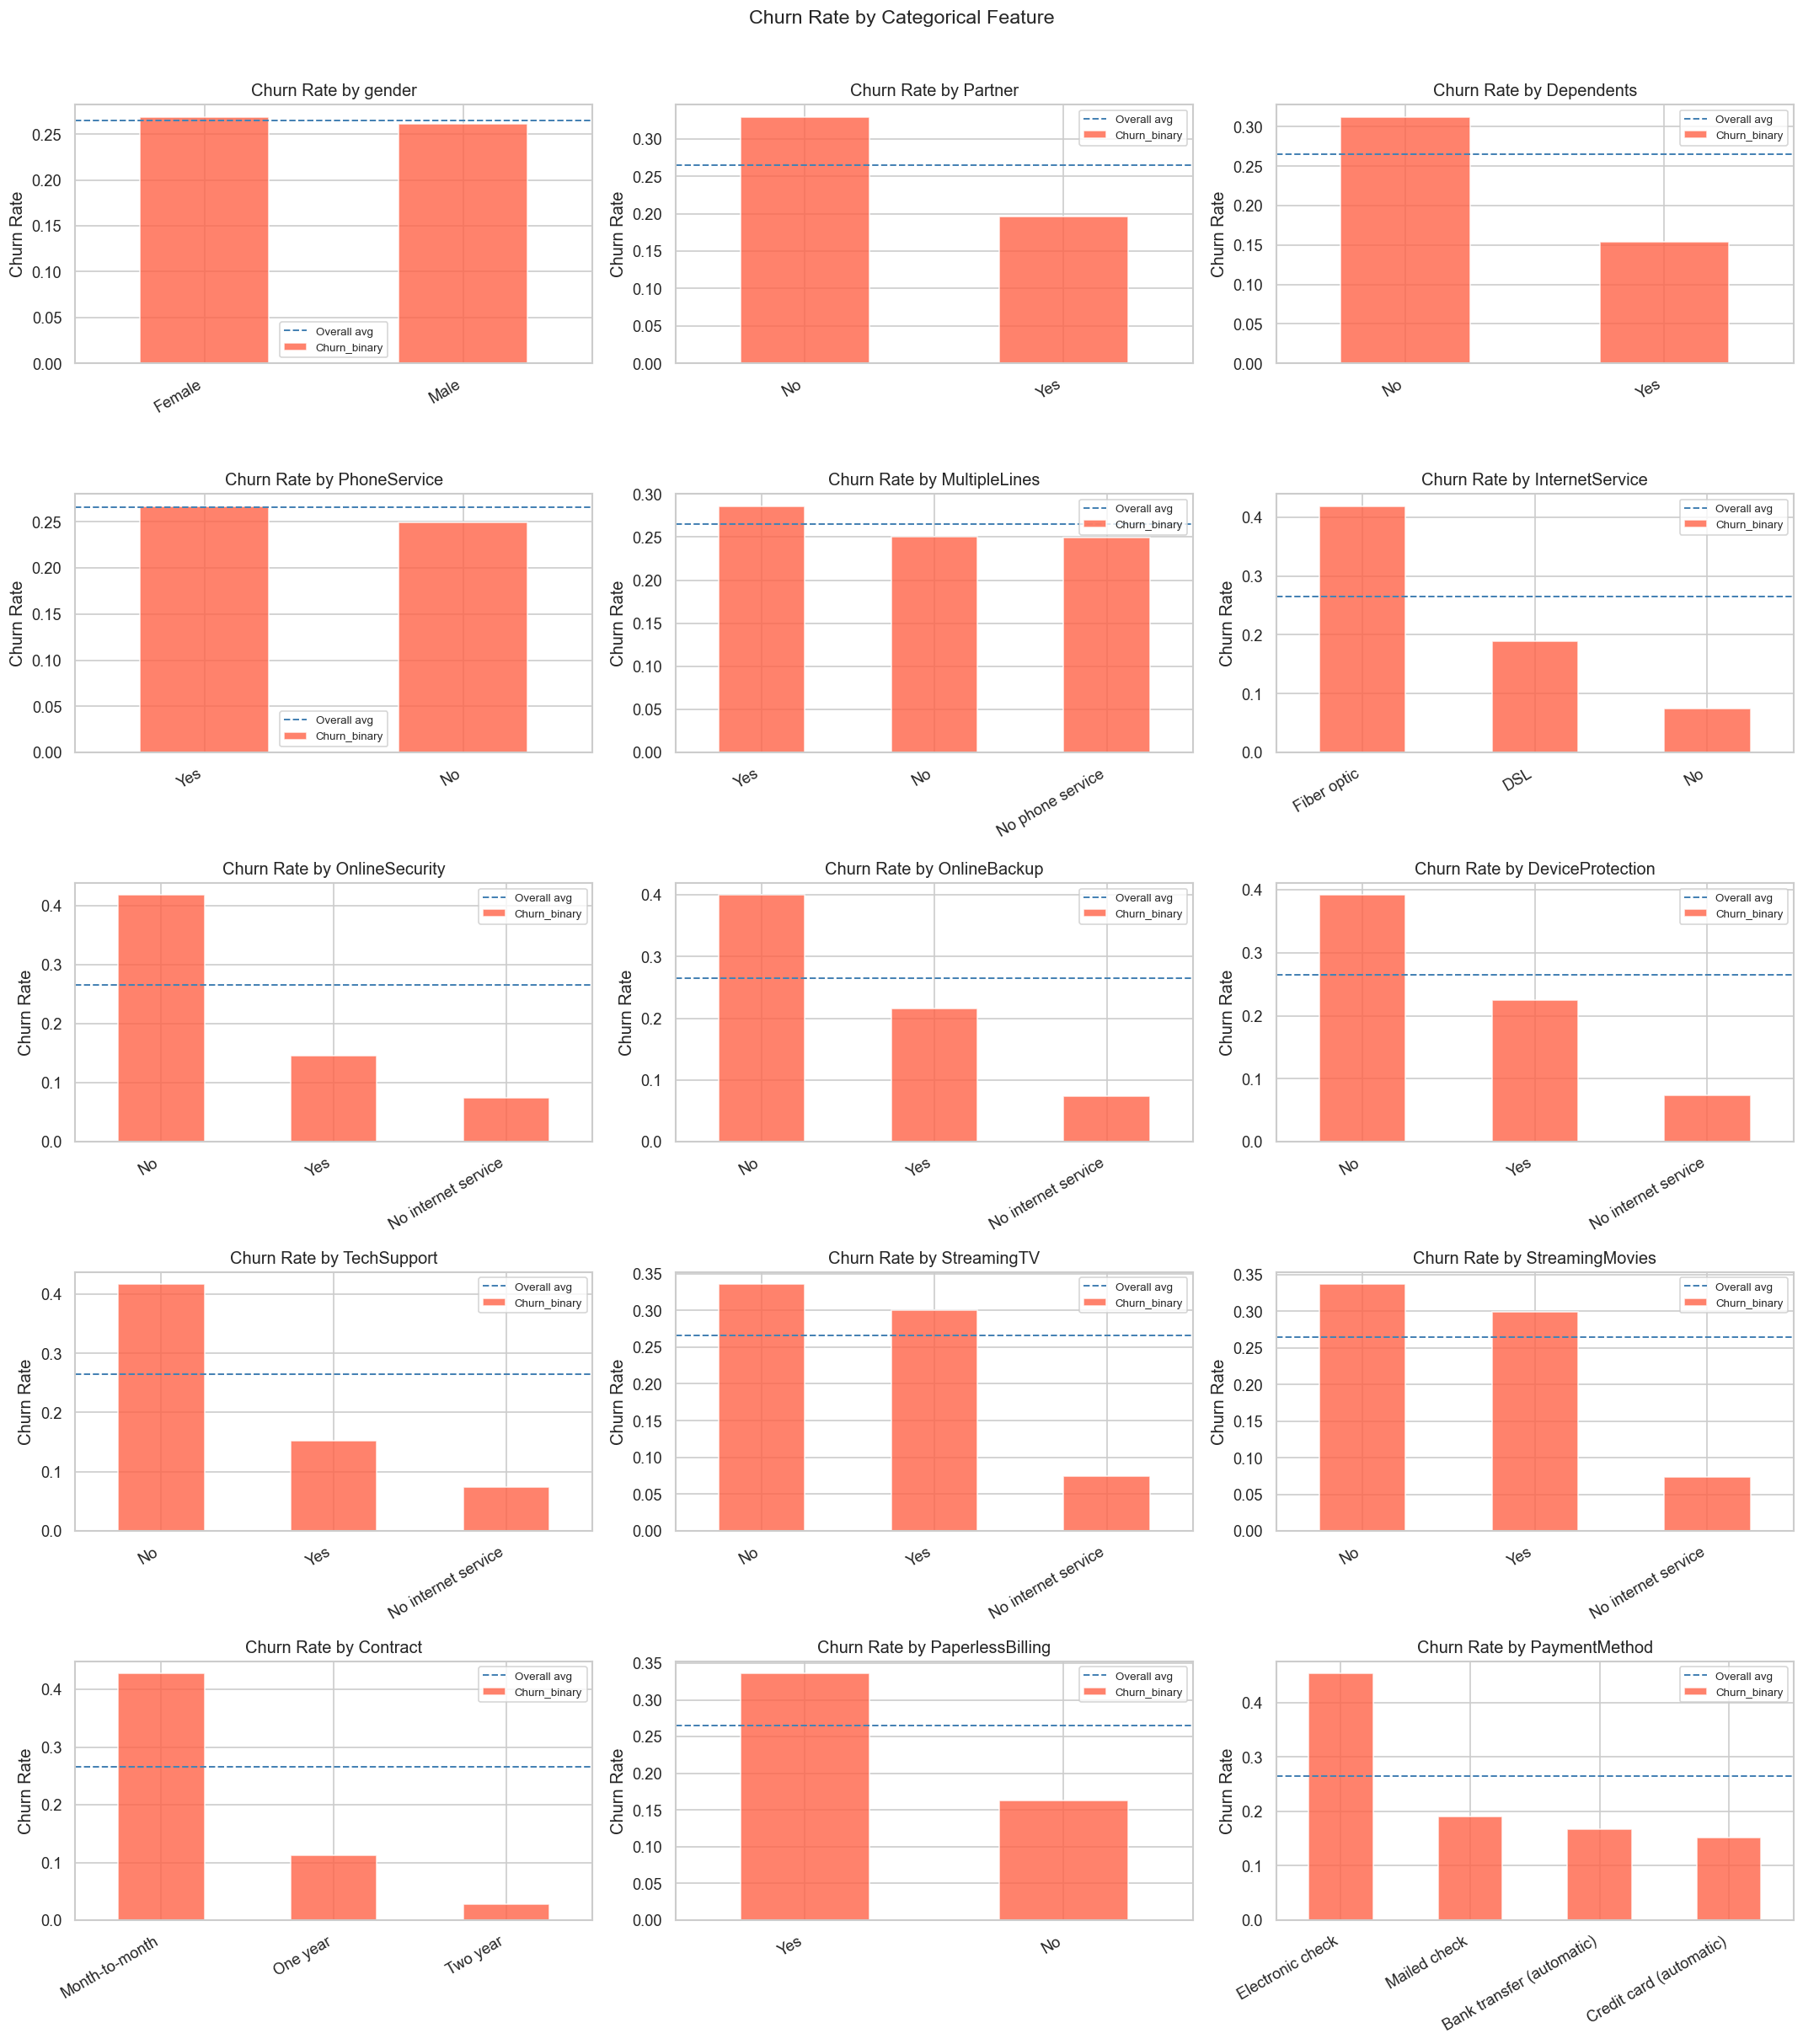

In [15]:
# Churn rate per category value
def plot_churn_rate_by_category(df, col, ax):
    rates = df.groupby(col)['Churn_binary'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='tomato', edgecolor='white', alpha=0.8)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.axhline(df['Churn_binary'].mean(), color='steelblue', linestyle='--', linewidth=1.2, label='Overall avg')
    ax.legend(fontsize=8)

n = len(cat_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    plot_churn_rate_by_category(df, col, axes[i])

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/categorical_churn_rates.png', bbox_inches='tight')
plt.show()

> **Key features to watch:**
> - `Contract` — month-to-month customers churn at a much higher rate
> - `InternetService` — fiber optic customers churn more
> - `PaymentMethod` — electronic check correlates strongly with churn
> - `OnlineSecurity`, `TechSupport` — customers without these churn more

---
## 7. Correlation Analysis

FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/numerical_correlation_target.png'

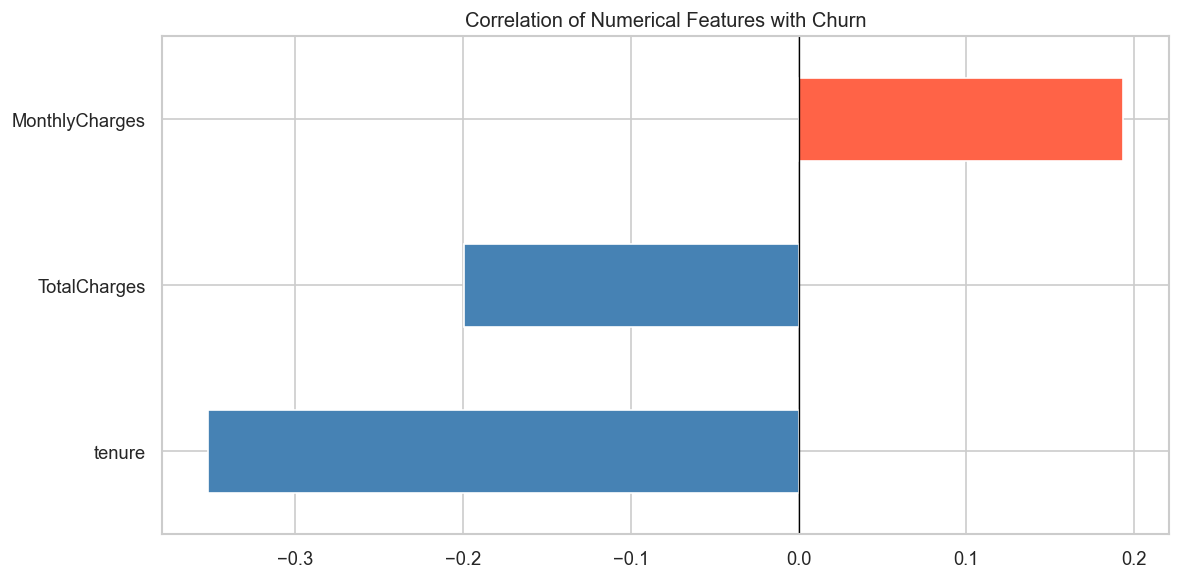

In [16]:
# Numerical correlation with target
corr_with_target = df[num_cols + ['Churn_binary']].corr()['Churn_binary'].drop('Churn_binary').sort_values()

corr_with_target.plot(kind='barh', color=['tomato' if v > 0 else 'steelblue' for v in corr_with_target])
plt.title('Correlation of Numerical Features with Churn')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/figures/numerical_correlation_target.png')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/correlation_heatmap.png'

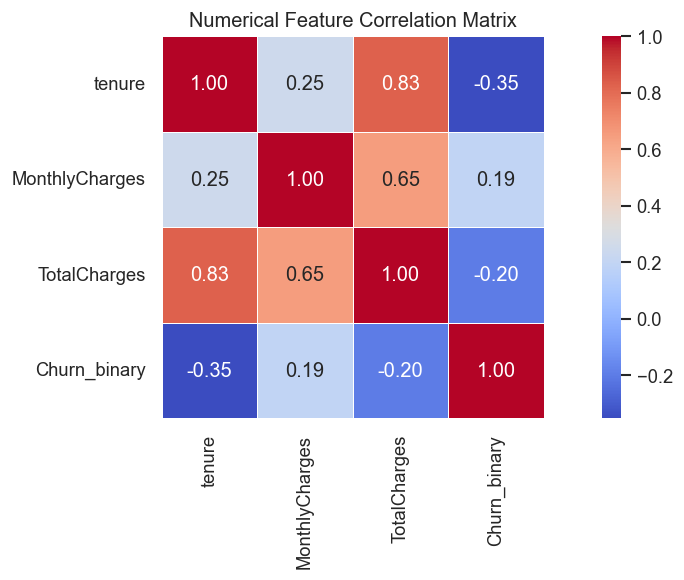

In [17]:
# Heatmap across all numerical features
corr_matrix = df[num_cols + ['Churn_binary']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Numerical Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png')
plt.show()

> **Note:** `tenure` and `TotalCharges` are highly correlated. Consider dropping `TotalCharges` or engineering a ratio feature (e.g. `monthly_to_total_ratio`) in the next notebook.

---
## 8. Churn by Tenure — Segment Analysis

FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/churn_by_tenure_group.png'

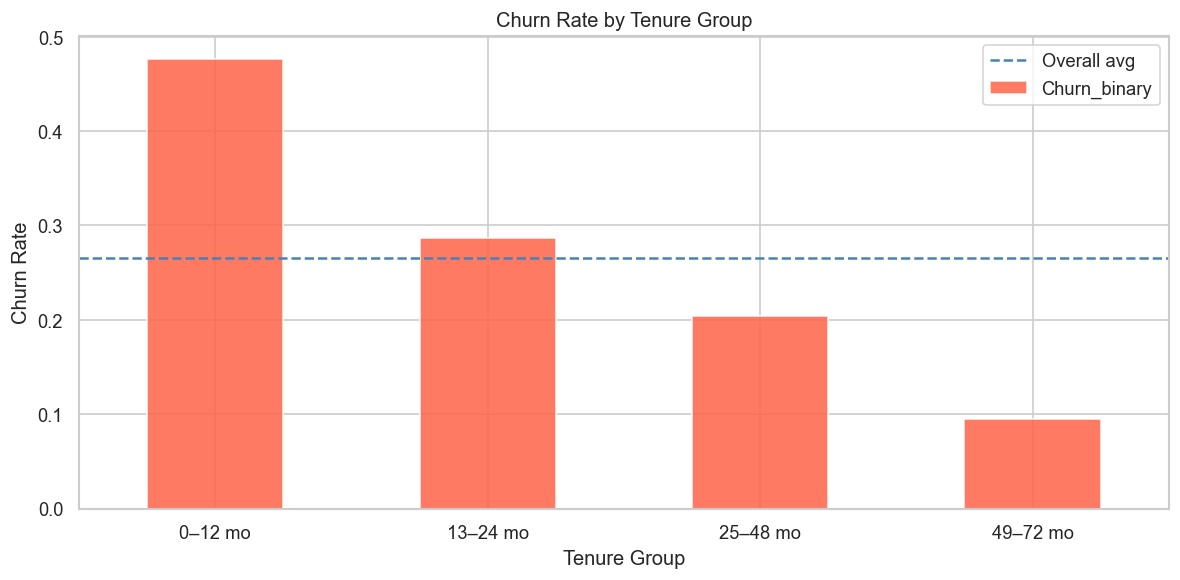

In [18]:
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0–12 mo', '13–24 mo', '25–48 mo', '49–72 mo'])

tenure_churn = df.groupby('tenure_group', observed=True)['Churn_binary'].mean()

tenure_churn.plot(kind='bar', color='tomato', edgecolor='white', alpha=0.85)
plt.axhline(df['Churn_binary'].mean(), color='steelblue', linestyle='--', label='Overall avg')
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate')
plt.xlabel('Tenure Group')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/churn_by_tenure_group.png')
plt.show()

---
## 9. Churn by Contract × Internet Service (Interaction)

In [ ]:
pivot = df.groupby(['Contract', 'InternetService'])['Churn_binary'].mean().unstack()

sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds', linewidths=0.5)
plt.title('Churn Rate: Contract × Internet Service')
plt.tight_layout()
plt.savefig('../reports/figures/churn_contract_internet.png')
plt.show()

---
## 10. EDA Summary & Findings

| Finding | Implication |
|---|---|
| ~26% churn rate | Imbalanced classification — avoid accuracy as metric |
| Low tenure → high churn | `tenure` is a strong predictor; consider tenure buckets |
| High monthly charges → higher churn | `MonthlyCharges` is informative; check for multicollinearity |
| `TotalCharges` ≈ `tenure × MonthlyCharges` | High collinearity — may drop or engineer ratio feature |
| Month-to-month contract → highest churn | `Contract` is likely the strongest categorical predictor |
| Fiber optic → higher churn | Possibly price-driven — interact with `MonthlyCharges` |
| Electronic check → higher churn | Payment friction may signal disengagement |
| No security/support services → higher churn | Add-on services correlate with retention |

### Features to Engineer (Next Notebook)
- `charge_per_month_ratio` = `TotalCharges / (tenure + 1)`
- `num_services` = count of active add-on services per customer
- `is_new_customer` = tenure ≤ 12
- Tenure buckets (already explored above)